In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Read in Year_GrowthDay_Abundance_Temp.csv from Viktoria's Results folder
df1 = pd.read_csv("Year_GrowthDay_Abundance_Temp.csv")
df1

,Year,Growth_mm_per_day,Growth_mm_per_month,R_squared,N,GM_Index,Mean_Temp
0,1979,0.394735,11.842040,0.470154,666,8.362842,NaN
1,1980,0.304794,9.143830,0.304468,983,10.172562,NaN
2,1981,0.320810,9.624290,0.453215,987,7.233661,NaN
3,1982,0.575138,17.254146,0.653726,351,1.923998,NaN
4,1984,0.601677,18.050320,0.676437,563,4.117481,NaN
5,1986,0.296179,8.885362,0.247485,1086,6.316636,22.790123
6,1987,0.486561,14.596845,0.552415,1343,12.981780,23.349398
7,1988,0.435776,13.073285,0.529400,906,5.905538,25.108434
8,1989,0.551059,16.531774,0.387293,867,5.151229,24.047619
9,1990,0.356238,10.687133,0.355862,1449,12.768370,23.407895


In [4]:
# Read in Monthly_Median_Lengths_By_Year.csv from Viktoria's Results folder
df2 = pd.read_csv("Monthly_Median_Lengths_By_Year.csv")
df2

,Year,July_Median,August_Median,September_Median,October_Median
0,1979,51.0,60.0,70.0,72.0
1,1980,65.0,71.0,81.0,80.0
2,1981,57.0,67.0,76.0,77.0
3,1982,51.0,65.0,81.0,96.0
4,1984,47.0,57.0,76.0,76.0
5,1986,53.0,63.5,72.0,84.0
6,1987,50.0,70.0,83.0,89.0
7,1988,49.0,68.0,81.0,84.0
8,1989,46.0,62.0,78.0,82.0
9,1990,42.0,54.0,66.0,75.0


In [5]:
# Read in Holyoke_adult_run_timing_summary.csv from Viktoria's Results folder
df3 = pd.read_csv("Holyoke_adult_run_timing_summary.csv")
df3

,Year,First_DOY,DOY_10,Median_DOY,Peak_DOY,DOY_90,Last_DOY,Duration,Total_Run
0,1976,125,137,151,151,157,169,20,346702.0
1,1977,120,127,139,136,148,196,21,202997.0
2,1978,130,143,147,147,150,184,7,144698.0
3,1979,123,130,136,131,155,190,25,254053.0
4,1980,120,133,141,139,150,182,17,376065.0
5,1981,118,128,145,146,151,212,23,377124.0
6,1982,130,135,142,137,152,196,17,294835.0
7,1983,133,143,161,165,166,196,23,528185.0
8,1984,123,143,148,145,168,202,25,496939.0
9,1985,115,131,144,146,153,196,22,481668.0


In [14]:
# Put both into one DataFrame
newdf = df1.copy().merge(df3)
newdf

,Year,Growth_mm_per_day,Growth_mm_per_month,R_squared,N,GM_Index,Mean_Temp,First_DOY,DOY_10,Median_DOY,Peak_DOY,DOY_90,Last_DOY,Duration,Total_Run
0,1979,0.394735,11.842040,0.470154,666,8.362842,NaN,123,130,136,131,155,190,25,254053.0
1,1980,0.304794,9.143830,0.304468,983,10.172562,NaN,120,133,141,139,150,182,17,376065.0
2,1981,0.320810,9.624290,0.453215,987,7.233661,NaN,118,128,145,146,151,212,23,377124.0
3,1982,0.575138,17.254146,0.653726,351,1.923998,NaN,130,135,142,137,152,196,17,294835.0
4,1984,0.601677,18.050320,0.676437,563,4.117481,NaN,123,143,148,145,168,202,25,496939.0
5,1986,0.296179,8.885362,0.247485,1086,6.316636,22.790123,111,127,137,137,149,196,22,352162.0
6,1987,0.486561,14.596845,0.552415,1343,12.981780,23.349398,112,130,141,137,151,187,21,271920.0
7,1988,0.435776,13.073285,0.529400,906,5.905538,25.108434,110,132,143,145,162,185,30,294157.0
8,1989,0.551059,16.531774,0.387293,867,5.151229,24.047619,116,139,149,143,158,195,19,354089.0
9,1990,0.356238,10.687133,0.355862,1449,12.768370,23.407895,113,122,147,155,159,194,37,363825.0


In [28]:
# Create a fitted line
slope, intercept = np.polyfit(newdf["Median_DOY"], newdf["Growth_mm_per_day"], 1)

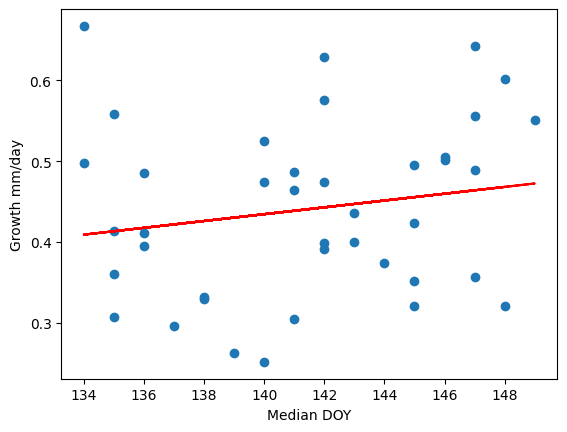

In [32]:
plt.scatter(newdf["Median_DOY"], newdf["Growth_mm_per_day"])
plt.plot(newdf["Median_DOY"], slope*np.array(newdf["Median_DOY"]) + intercept, color='red')
plt.xlabel("Median DOY")
plt.ylabel("Growth mm/day")
plt.show()

In [33]:
pearson_corr = newdf["Median_DOY"].corr(newdf["Growth_mm_per_day"]) 
spearman_corr = newdf["Median_DOY"].corr(newdf["Growth_mm_per_day"], method='spearman')

print(f"Pearson: {pearson_corr}, Spearman: {spearman_corr}")

Pearson: 0.17633167571591526, Spearman: 0.19884350442950482


In [ ]:
# As the coefficients are less than 0.8, there's likely no correlation.

In [ ]:
###########################################################################################################

In [34]:
slope, intercept = np.polyfit(newdf["Duration"], newdf["Growth_mm_per_day"], 1)

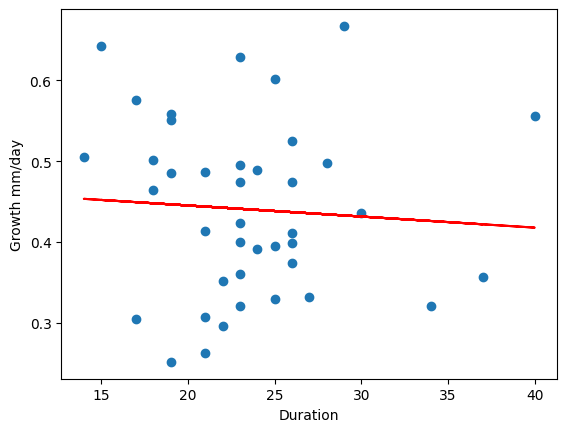

In [35]:
plt.scatter(newdf["Duration"], newdf["Growth_mm_per_day"])
plt.plot(newdf["Duration"], slope*np.array(newdf["Duration"]) + intercept, color='red')
plt.xlabel("Duration")
plt.ylabel("Growth mm/day")
plt.show()

In [36]:
pearson_corr = newdf["Duration"].corr(newdf["Growth_mm_per_day"]) 
spearman_corr = newdf["Duration"].corr(newdf["Growth_mm_per_day"], method='spearman')

print(f"Pearson: {pearson_corr}, Spearman: {spearman_corr}")

Pearson: -0.06829812828969348, Spearman: -0.06843973630881324


In [ ]:
# As the coefficients are less than 0.8, there's likely no correlation.

In [ ]:
###########################################################################################################

In [37]:
slope, intercept = np.polyfit(newdf["Median_DOY"], newdf["GM_Index"], 1)

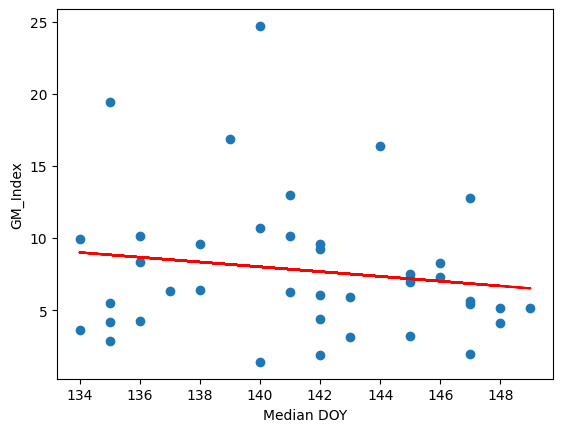

In [38]:
plt.scatter(newdf["Median_DOY"], newdf["GM_Index"])
plt.plot(newdf["Median_DOY"], slope*np.array(newdf["Median_DOY"]) + intercept, color='red')
plt.xlabel("Median DOY")
plt.ylabel("GM_Index")
plt.show()

In [39]:
pearson_corr = newdf["Median_DOY"].corr(newdf["GM_Index"]) 
spearman_corr = newdf["Median_DOY"].corr(newdf["GM_Index"], method='spearman')

print(f"Pearson: {pearson_corr}, Spearman: {spearman_corr}")

Pearson: -0.1516751246487132, Spearman: -0.15668454087795813


In [ ]:
# As the coefficients are less than 0.8, there's likely no correlation.

In [40]:
logged = np.log(newdf['GM_Index'])

In [41]:
slope, intercept = np.polyfit(newdf["Median_DOY"], logged, 1)

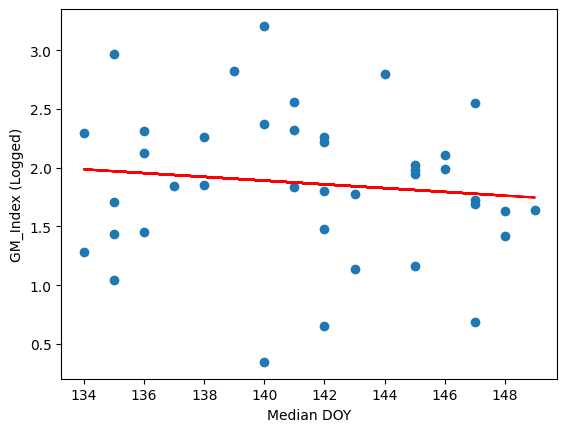

In [42]:
plt.scatter(newdf["Median_DOY"], logged)
plt.plot(newdf["Median_DOY"], slope*np.array(newdf["Median_DOY"]) + intercept, color='red')
plt.xlabel("Median DOY")
plt.ylabel("GM_Index (Logged)")
plt.show()

In [43]:
pearson_corr = newdf["Median_DOY"].corr(logged) 
spearman_corr = newdf["Median_DOY"].corr(logged, method='spearman')

print(f"Pearson: {pearson_corr}, Spearman: {spearman_corr}")

Pearson: -0.11495280791764463, Spearman: -0.15668454087795813


In [ ]:
# As the coefficients are less than 0.8, there's likely no correlation.

In [ ]:
###########################################################################################################

In [44]:
newdf2 = df2.copy().merge(df3)
newdf2

,Year,July_Median,August_Median,September_Median,October_Median,First_DOY,DOY_10,Median_DOY,Peak_DOY,DOY_90,Last_DOY,Duration,Total_Run
0,1979,51.0,60.0,70.0,72.0,123,130,136,131,155,190,25,254053.0
1,1980,65.0,71.0,81.0,80.0,120,133,141,139,150,182,17,376065.0
2,1981,57.0,67.0,76.0,77.0,118,128,145,146,151,212,23,377124.0
3,1982,51.0,65.0,81.0,96.0,130,135,142,137,152,196,17,294835.0
4,1984,47.0,57.0,76.0,76.0,123,143,148,145,168,202,25,496939.0
5,1986,53.0,63.5,72.0,84.0,111,127,137,137,149,196,22,352162.0
6,1987,50.0,70.0,83.0,89.0,112,130,141,137,151,187,21,271920.0
7,1988,49.0,68.0,81.0,84.0,110,132,143,145,162,185,30,294157.0
8,1989,46.0,62.0,78.0,82.0,116,139,149,143,158,195,19,354089.0
9,1990,42.0,54.0,66.0,75.0,113,122,147,155,159,194,37,363825.0


In [45]:
slope, intercept = np.polyfit(newdf2["Median_DOY"], newdf2["July_Median"], 1)

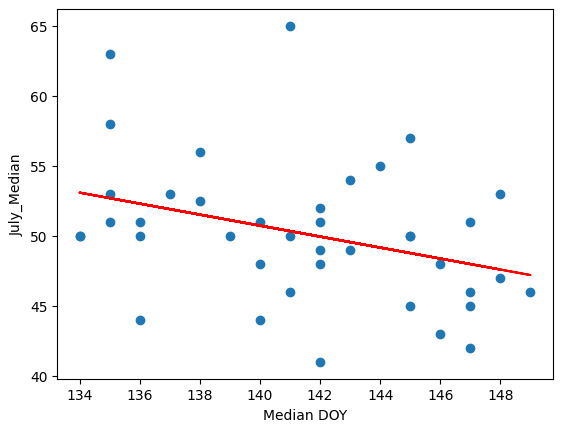

In [46]:
plt.scatter(newdf2["Median_DOY"], newdf2["July_Median"])
plt.plot(newdf2["Median_DOY"], slope*np.array(newdf2["Median_DOY"]) + intercept, color='red')
plt.xlabel("Median DOY")
plt.ylabel("July_Median")
plt.show()

In [47]:
pearson_corr = newdf2["Median_DOY"].corr(newdf2["July_Median"]) 
spearman_corr = newdf2["Median_DOY"].corr(newdf2["July_Median"], method='spearman')

print(f"Pearson: {pearson_corr}, Spearman: {spearman_corr}")

Pearson: -0.34761658977488175, Spearman: -0.3583312010508586


In [ ]:
# The correlation coefficients are higher than the above comparisons, but as the coefficients are still less than 0.8, there's likely no correlation.

In [ ]:
###########################################################################################################

In [48]:
slope, intercept = np.polyfit(newdf2["Median_DOY"], newdf2["September_Median"], 1)

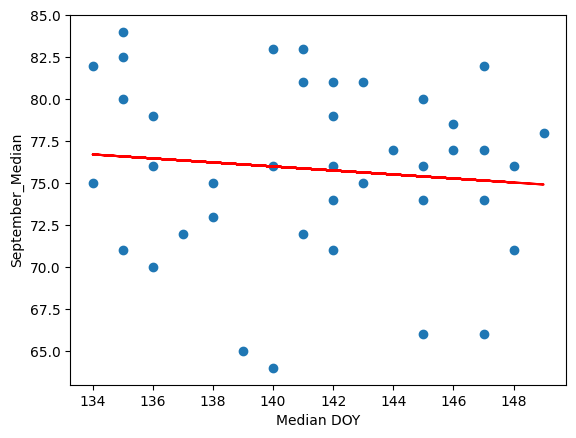

In [49]:
plt.scatter(newdf2["Median_DOY"], newdf2["September_Median"])
plt.plot(newdf2["Median_DOY"], slope*np.array(newdf2["Median_DOY"]) + intercept, color='red')
plt.xlabel("Median DOY")
plt.ylabel("September_Median")
plt.show()

In [50]:
pearson_corr = newdf2["Median_DOY"].corr(newdf2["September_Median"]) 
spearman_corr = newdf2["Median_DOY"].corr(newdf2["September_Median"], method='spearman')

print(f"Pearson: {pearson_corr}, Spearman: {spearman_corr}")

Pearson: -0.10397618238162397, Spearman: -0.08780124076552673


In [ ]:
# As the coefficients are less than 0.8, there's likely no correlation.

In [ ]:
###########################################################################################################